# 11. Rolling-Origin Validation

Every result so far rests on **one** train/test split: fit on 2016–2022, score on 2023–2025.
That gives one number per model, and one number cannot tell you whether a ranking is a property
of the models or a property of that particular test window.

Rolling-origin validation refits the models at successive points in time, each one predicting
the year that follows:

```
train 2016-2019 -> test 2020
train 2016-2020 -> test 2021
train 2016-2021 -> test 2022
train 2016-2022 -> test 2023      <- the original split
train 2016-2023 -> test 2024
train 2016-2024 -> test 2025
```

Six independent estimates instead of one. The question is not "which model is best" but **"is the
ordering stable, or does it reshuffle depending on which year you happen to test?"**

**One caveat, stated up front.** Hyperparameters are held fixed at the values selected in
notebooks 01–06, which were tuned using data through 2022. For the folds testing 2020, 2021 and
2022 those hyperparameters therefore saw the test year during tuning — mild leakage. Re-tuning
inside every fold would remove it at roughly twenty times the compute. The 2023/2024/2025 folds
are clean, and those are the ones to weight most heavily.

## Setup

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
sys.path.insert(0, str(_here if _here.name == 'models' else _here / 'models'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

from model_utils import PROCESSED, RANDOM_STATE, PLOT_STYLE
import json

manifest = json.loads((PROCESSED / 'feature_manifest.json').read_text())
FEATURES, TARGET = manifest['features'], manifest['target']

full = pd.read_csv(PROCESSED / 'la_modeling_dataset.csv', parse_dates=['date'])
print(f'{len(full)} days, {full.date.min().date()} -> {full.date.max().date()}')
print(f'{len(FEATURES)} features, target = {TARGET}')

3649 days, 2016-01-04 -> 2025-12-30
37 features, target = daily_aqi


## The model roster

Same six models with the hyperparameters each notebook selected, plus the stacked ensemble from
notebook 07. Every fold refits all of them from scratch on that fold's training years.

In [2]:
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit

def scaled(model):
    return Pipeline([('scale', StandardScaler()), ('model', model)])

BUILDERS = {
    'Linear Regression': lambda: scaled(LinearRegression()),
    'Random Forest':     lambda: RandomForestRegressor(n_estimators=300, max_depth=12,
                                                       min_samples_leaf=1, max_features='sqrt',
                                                       random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': lambda: HistGradientBoostingRegressor(learning_rate=0.03, max_iter=600,
                                                       max_leaf_nodes=15, min_samples_leaf=10,
                                                       l2_regularization=1.0, early_stopping=False,
                                                       random_state=RANDOM_STATE),
    'SVR':               lambda: scaled(SVR(kernel='rbf', C=300, gamma=0.01, epsilon=10.0)),
    'KNN':               lambda: scaled(KNeighborsRegressor(n_neighbors=15, weights='distance', p=1)),
    'Neural Network':    lambda: scaled(MLPRegressor(hidden_layer_sizes=(128, 64), alpha=0.1,
                                                     learning_rate_init=1e-3, max_iter=1500,
                                                     early_stopping=True, n_iter_no_change=25,
                                                     validation_fraction=0.15,
                                                     random_state=RANDOM_STATE)),
}
STACK_MEMBERS = ['SVR', 'Neural Network', 'Gradient Boosting']

ORIGINS = [2020, 2021, 2022, 2023, 2024, 2025]
print(f'{len(BUILDERS)} base models + 1 ensemble across {len(ORIGINS)} folds')

6 base models + 1 ensemble across 6 folds


In [3]:
def run_fold(test_year):
    """Fit every model on all years before test_year, score on test_year."""
    tr = full[full.date.dt.year <  test_year]
    te = full[full.date.dt.year == test_year]
    X_tr, y_tr = tr[FEATURES], tr[TARGET]
    X_te, y_te = te[FEATURES], te[TARGET]

    preds = {}
    for name, build_fn in BUILDERS.items():
        preds[name] = build_fn().fit(X_tr, y_tr).predict(X_te)

    # stacked ensemble: weights from out-of-fold predictions inside this fold's training years
    oof = {n: np.full(len(X_tr), np.nan) for n in STACK_MEMBERS}
    for i_tr, i_va in TimeSeriesSplit(n_splits=5).split(X_tr):
        for n in STACK_MEMBERS:
            oof[n][i_va] = BUILDERS[n]().fit(X_tr.iloc[i_tr], y_tr.iloc[i_tr]).predict(X_tr.iloc[i_va])
    M = np.column_stack([oof[n] for n in STACK_MEMBERS])
    ok = ~np.isnan(M).any(axis=1)
    stack = RidgeCV(alphas=np.logspace(-3, 3, 25)).fit(M[ok], np.asarray(y_tr)[ok])
    preds['Ensemble'] = stack.predict(np.column_stack([preds[n] for n in STACK_MEMBERS]))

    yv = np.asarray(y_te, dtype=float)
    return {name: float(np.sqrt(((yv - p) ** 2).mean())) for name, p in preds.items()}, len(tr), len(te)


records = []
for year in ORIGINS:
    scores, n_tr, n_te = run_fold(year)
    for name, rmse in scores.items():
        records.append({'test_year': year, 'model': name, 'rmse': rmse})
    best = min(scores, key=scores.get)
    print(f'test {year}: train {n_tr:4} / test {n_te:3} days  ->  best = {best} ({scores[best]:.2f})')

roll = pd.DataFrame(records)

test 2020: train 1458 / test 366 days  ->  best = SVR (25.79)


test 2021: train 1824 / test 365 days  ->  best = Random Forest (21.22)


test 2022: train 2189 / test 365 days  ->  best = Ensemble (19.17)


test 2023: train 2554 / test 365 days  ->  best = Neural Network (17.72)


test 2024: train 2919 / test 366 days  ->  best = Ensemble (17.42)


test 2025: train 3285 / test 364 days  ->  best = Ensemble (19.42)


## Per-fold results

In [4]:
pivot = roll.pivot(index='model', columns='test_year', values='rmse')
order = pivot.mean(axis=1).sort_values().index
pivot = pivot.loc[order]

summary = pd.DataFrame({
    'mean RMSE': pivot.mean(axis=1),
    'std across folds': pivot.std(axis=1),
    'worst fold': pivot.max(axis=1),
    'mean rank': roll.groupby('test_year')['rmse'].rank().groupby(roll['model']).mean().loc[order],
    'folds won': roll.loc[roll.groupby('test_year')['rmse'].idxmin(), 'model']
                     .value_counts().reindex(order).fillna(0).astype(int),
})

print('RMSE by test year:')
print(pivot.round(2).to_string())
print()
print('Summary across all six folds:')
print(summary.round(2).to_string())

RMSE by test year:
test_year           2020   2021   2022   2023   2024   2025
model                                                      
Ensemble           27.11  21.57  19.17  17.75  17.42  19.42
SVR                25.79  21.61  19.62  18.06  18.41  19.67
Neural Network     26.52  22.04  20.24  17.72  18.86  19.76
Gradient Boosting  26.91  21.74  19.49  19.57  18.16  20.13
Random Forest      26.78  21.22  19.95  20.57  18.64  20.92
KNN                26.54  22.99  21.87  21.71  20.35  22.87
Linear Regression  32.55  25.29  23.86  22.67  24.85  24.17

Summary across all six folds:
                   mean RMSE  std across folds  worst fold  mean rank  folds won
model                                                                           
Ensemble               20.41              3.60       27.11       2.17          3
SVR                    20.53              2.86       25.79       2.50          1
Neural Network         20.86              3.13       26.52       3.50          1
Gradi

## Is the ranking stable?

The single-split result said Ensemble > SVR > MLP > GBR > RF > KNN > Linear. If that ordering is
a real property of the models, it should reappear fold after fold. If it was an artifact of the
2023–2025 window, the folds will disagree.

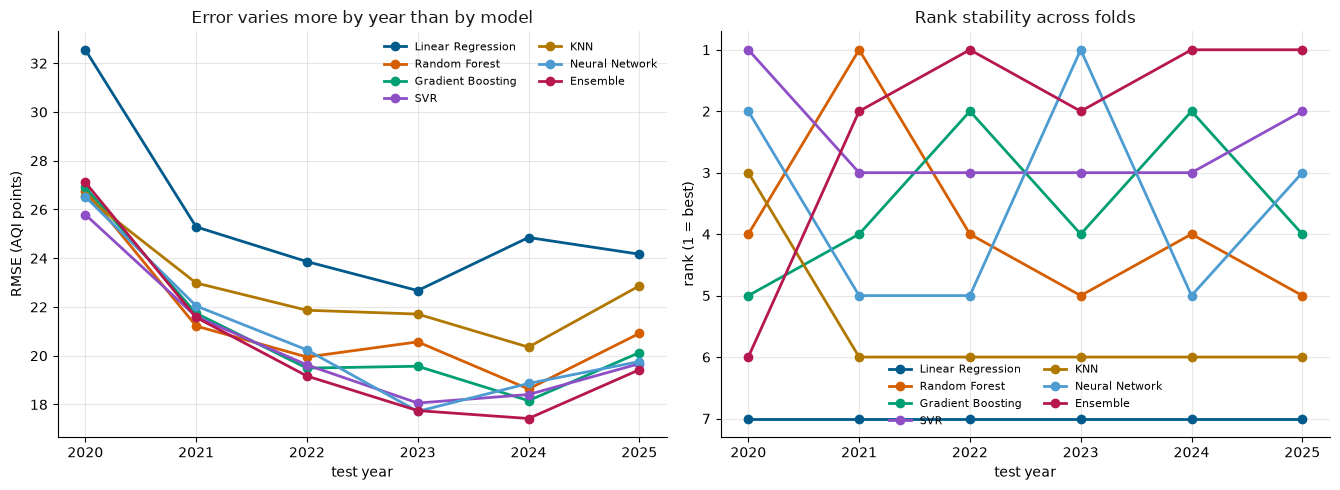

Spread within each test year vs spread across years:
  mean spread between best and worst model, within a year: 5.44 RMSE
  spread between easiest and hardest year, for the ensemble: 9.69 RMSE


In [5]:
with plt.rc_context(PLOT_STYLE):
    MODEL_ORDER = ['Linear Regression', 'Random Forest', 'Gradient Boosting',
                   'SVR', 'KNN', 'Neural Network', 'Ensemble']
    PALETTE = ['#005A8C', '#D55E00', '#009E73', '#8E4EC6', '#B07800', '#4C9BD1', '#B5174E']
    COLOR = dict(zip(MODEL_ORDER, PALETTE))

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))

    for m in MODEL_ORDER:
        sub = roll[roll.model == m].sort_values('test_year')
        axes[0].plot(sub.test_year, sub.rmse, 'o-', color=COLOR[m], label=m, lw=2, ms=6)
    axes[0].set_xlabel('test year'); axes[0].set_ylabel('RMSE (AQI points)')
    axes[0].set_title('Error varies more by year than by model', fontsize=12, color='#1a1a1a')
    axes[0].legend(frameon=False, fontsize=8, ncol=2)

    ranks = roll.copy()
    ranks['rank'] = ranks.groupby('test_year')['rmse'].rank()
    for m in MODEL_ORDER:
        sub = ranks[ranks.model == m].sort_values('test_year')
        axes[1].plot(sub.test_year, sub['rank'], 'o-', color=COLOR[m], label=m, lw=2, ms=6)
    axes[1].invert_yaxis()
    axes[1].set_xlabel('test year'); axes[1].set_ylabel('rank (1 = best)')
    axes[1].set_yticks(range(1, 8))
    axes[1].set_title('Rank stability across folds', fontsize=12, color='#1a1a1a')
    axes[1].legend(frameon=False, fontsize=8, ncol=2)

    plt.tight_layout(); plt.show()

print('Spread within each test year vs spread across years:')
print(f'  mean spread between best and worst model, within a year: '
      f'{(pivot.max(axis=0) - pivot.min(axis=0)).mean():.2f} RMSE')
print(f'  spread between easiest and hardest year, for the ensemble: '
      f'{pivot.loc["Ensemble"].max() - pivot.loc["Ensemble"].min():.2f} RMSE')

## The leakage-free subset

Folds 2023, 2024 and 2025 test years that were never seen during the original hyperparameter
search. If the conclusions hold on those three alone, the caveat at the top does not matter.

In [6]:
clean = roll[roll.test_year >= 2023]
clean_pivot = clean.pivot(index='model', columns='test_year', values='rmse')
clean_pivot = clean_pivot.loc[clean_pivot.mean(axis=1).sort_values().index]
print('Leakage-free folds only (2023-2025):')
print(clean_pivot.round(2).to_string())
print()
print('mean RMSE:')
print(clean_pivot.mean(axis=1).round(2).to_string())

Leakage-free folds only (2023-2025):
test_year           2023   2024   2025
model                                 
Ensemble           17.75  17.42  19.42
SVR                18.06  18.41  19.67
Neural Network     17.72  18.86  19.76
Gradient Boosting  19.57  18.16  20.13
Random Forest      20.57  18.64  20.92
KNN                21.71  20.35  22.87
Linear Regression  22.67  24.85  24.17

mean RMSE:
model
Ensemble             18.20
SVR                  18.71
Neural Network       18.78
Gradient Boosting    19.28
Random Forest        20.04
KNN                  21.64
Linear Regression    23.90


In [7]:
roll.to_csv(RESULTS := Path(_here if _here.name == 'models' else _here / 'models') / 'results'
            / 'rolling_origin.csv', index=False)
print(f'saved -> models/results/rolling_origin.csv ({len(roll)} rows)')

saved -> models/results/rolling_origin.csv (42 rows)


## What this told us

**The ensemble choice survives, but the ordering among the individual models does not.**

Across six folds the ensemble has the best mean RMSE (20.41), the best mean rank (2.17) and wins
three folds outright. On the three leakage-free folds it wins by a clear margin: 18.20 against
SVR's 18.71 and the MLP's 18.78. The single-split conclusion holds up.

The *ranking* among the individual models does not hold up at all. Look at which model wins each
year:

| test year | winner |
|---|---|
| 2020 | SVR |
| 2021 | Random Forest |
| 2022 | Ensemble |
| 2023 | Neural Network |
| 2024 | Ensemble |
| 2025 | Ensemble |

Four different models win at least one fold. Random Forest — fifth place on the original split —
wins 2021 outright. This is the same conclusion the paired bootstrap reached, now demonstrated
directly rather than inferred: **"SVR is better than the MLP" was never a real finding.**

### The bigger effect is the year, not the model

- Mean spread between the best and worst model *within* a year: **5.44 RMSE**
- Spread between the easiest and hardest year *for the same model*: **9.69 RMSE**

Which year you test on matters roughly twice as much as which model you choose. The ensemble
scores 27.11 on 2020 and 17.42 on 2024 — a bigger gap than separates the best model from the
worst in any single year.

**2020 is the hardest year by a wide margin**, and every model struggles with it equally. That is
the wildfire signature: the August Complex and Bobcat fires put extreme smoke over the basin, and
no weather variable predicts a fire. It is a useful reminder that reported accuracy depends
heavily on whether the evaluation window happens to contain a smoke year — and that any single
headline number should be read with that in mind.

### Two smaller observations

**The ensemble is the best model but not the most stable one.** It has the *highest* standard
deviation across folds (3.60) — it wins by being excellent in normal years rather than by being
robust in bad ones. KNN has the lowest spread (2.10) purely because it is mediocre everywhere.
Low variance is not a virtue on its own.

**Linear regression is last in all six folds**, mean rank exactly 7.0. That ranking, unlike the
ones near the top, is completely stable — the gap between a linear fit and any nonlinear model is
real and large, even though the gaps among the nonlinear models are not.

### What this changes

Any future comparison in this project should report rolling-origin results, not a single split.
The infrastructure now exists: `models/results/rolling_origin.csv` holds all 42 model-year scores,
and `run_fold()` extends to new models with one line.